# MIDTERM PROJECT_ BY ABDULSAMAD NURADEEN

**Predicting Housing Prices in Buenos Aires Project!**

Importing files

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import VimeoVideo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.utils.validation import check_is_fitted

In [13]:
def wrangle(filepath):
  df = pd.read_csv(filepath)

  # Subset property in `"Capital Federal"`
  mask_ba = df['place_with_parent_names'].str.contains('Capital Federal')

  # Subset to apartment
  mask_apt = df['property_type'] == 'apartment'

  # Subset property where `"price appro usd"` < 400,000
  mask_price = df['price_aprox_usd'] < 400_000

  df = df[mask_ba & mask_apt & mask_price]

  # Remove outliers
  low, high = df['surface_covered_in_m2'].quantile([0.1, 0.9])
  mask_area = df['surface_covered_in_m2'].between(low, high)
  return df

In [14]:
df = wrangle('/content/buenos-aires-real-estate-1.csv')
print('df shapes: ', df.shape)
df.head()

df shapes:  (1781, 16)


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Argentina|Capital Federal|Villa Crespo|,"-34.6047834183,-58.4586812499",180000.0,USD,2729232.0,180000.0,120.0,110.0,1500.000000,1636.363636,NaN,4.0,NaN,http://villa-crespo.properati.com.ar/12egq_ven...
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,"-34.5846508988,-58.4546932614",129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,"-34.6389789,-58.500115",87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...
11,sell,apartment,|Argentina|Capital Federal|Once|,"-34.6050060697,-58.4001162302",60000.0,USD,909744.0,60000.0,28.0,28.0,2142.857143,2142.857143,NaN,1.0,NaN,http://once.properati.com.ar/zz0q_venta_depart...
20,sell,apartment,|Argentina|Capital Federal|San Nicolás|,"-34.603898,-58.378617",69000.0,USD,1046205.6,69000.0,NaN,22.0,NaN,3136.363636,23.0,2.0,NaN,http://san-nicolas.properati.com.ar/rnju_venta...


# Exploratory Data Analysis(EDA)

**Distribution of Apartment Sizes**

Text(0.5, 1.0, 'Distribution of Apartment Sizes')

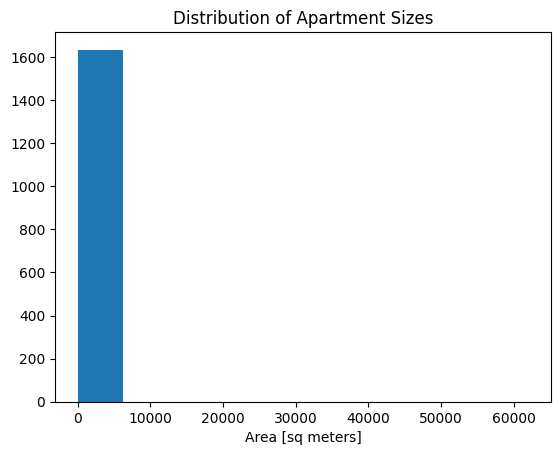

In [16]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes")